# 04 — Revision analyses

Label-alignment, dual-metric scoring, scaling (14B), and full-precision checks for the R&R. Runs are read from `results/past_runs/<run_type>/`.

## 1. Setup

Loads the config, repo names, and ground-truth label map, and defines the plotting palette and `style()` helper used by every figure below. Run this first — everything else depends on it.

In [2]:
import json, math, statistics
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import plotly.graph_objects as go
import yaml

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_cfg = yaml.safe_load(open(REPO_ROOT / "config.yaml"))
BENCHMARK_REPO = _cfg["compiled_dataset"]["repo_id"]
RESULTS_REPO = _cfg["results_repo"]["repo_id"]
prompt_version = _cfg.get("experiment", {}).get("prompt_version", "v1")
GROUND_TRUTH_TO_PIICODEX = json.load(open(REPO_ROOT / "config" / "pii_label_to_piicodex.json"))

CONDITIONS = ["zero_shot", "with_docs", "with_tools", "with_skills"]
CLABEL = {"zero_shot": "Zero-shot", "with_docs": "+Docs", "with_tools": "+Tool", "with_skills": "+Skills"}
INK, TEAL, TAUPE, SAGE = "#5C6B73", "#3D5A6C", "#9A8C7D", "#8B9E6B"

def style(fig, title="", h=420, w=720, **layout):
    base = dict(title=title, plot_bgcolor="#fafafa", height=h, width=w,
                legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
                margin=dict(t=44, b=72))
    base.update(layout)
    base.setdefault("yaxis", dict(gridcolor="#e0e0e0"))
    fig.update_layout(**base)
    
    return fig

## 2. Load runs

Defines `load_run`, which pulls any run's records from `results/past_runs/<run_type>/` (or the HuggingFace split), and loads the main run into `main`. This is the data every later section scores against.

In [3]:
def _benchmark_by_id():
    """Local dehydrated benchmark (anonymous bundle) or HuggingFace test split."""
    local = REPO_ROOT / "config" / "benchmark_test.json"
    if local.exists():
        payload = json.load(open(local))
        rows = payload.get("samples") if isinstance(payload, dict) else payload
        return {(row.get("id") or row.get("sample_id")): row for row in rows}
    from datasets import load_dataset
    bench = load_dataset(BENCHMARK_REPO, split="test")
    return {(row.get("id") or i): row for i, row in enumerate(bench)}

def load_run(run_type, pv=None):
    """Records for a run: local past_runs first, else HF split <run_type>_<pv>. [] if absent."""
    pv = pv or prompt_version
    local = REPO_ROOT / "results" / "past_runs" / run_type / "experiment_results.json"
    if local.exists():
        return json.load(open(local))
    try:
        from datasets import load_dataset
        res = load_dataset(RESULTS_REPO, split=f"{run_type}_{pv}")
        bench_by_id = _benchmark_by_id()
        out = []
        for r in res:
            b = bench_by_id.get(r["sample_id"], {})
            gt = b.get("pii_codex_ground_truth") or b.get("ground_truth") or []
            if isinstance(gt, str): gt = json.loads(gt) if gt else []
            if gt and isinstance(gt[0], str): gt = [{"type": t} for t in gt]
            preds = r.get("predictions"); preds = json.loads(preds) if isinstance(preds, str) else (preds or [])
            out.append({"sample_id": r["sample_id"], "source": r.get("source", ""), "model": r["model"],
                        "condition": r["condition"], "predictions": preds,
                        "ground_truth": gt if isinstance(gt, list) else [],
                        "tool_executed": bool(r.get("tool_executed"))})
        return out
    except Exception:
        return []

main = load_run("main")
print({m: sum(r["model"] == m for r in main) // 4 for m in sorted({r["model"] for r in main})}, "samples/condition")

{'gemma2_9b': 2000, 'llama3_8b': 2000, 'mistral_7b': 2000, 'qwen2_7b': 2000} samples/condition


## 3. Symmetric alignment + scoring

One map (ground-truth map + prediction aliases + the bridges below) applied identically to predictions and ground truth. Two metrics: type-only and span IoU≥0.5.

In [4]:
PREDICTION_TO_PIICODEX = {
    # Identity (model outputs canonical PII Codex type name)
    "US_BANK_ACCOUNT_NUMBER": "US_BANK_ACCOUNT_NUMBER",
    "US_DRIVERS_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION": "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION",
    "NRP": "NRP",  # Nationality, religion, political (PII Codex PIIType)
    # Driver / license
    "DRIVER_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_DRIVER_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    "DRIVER'S_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    # SSN
    "SOCIAL_SECURITY_NUMBER": "US_SOCIAL_SECURITY_NUMBER",
    # Postal / zip
    "POSTAL_CODE": "ZIPCODE",
    "US_POSTAL_CODE": "ZIPCODE",
    # Location (COUNTRY_OF_ORIGIN -> LOCATION per paper Appendix A.2)
    "COUNTRY_OF_ORIGIN": "LOCATION",
    # Person / account
    "ACCOUNT_USERNAME": "PERSON",
    "SIBLING_NAME": "PERSON",
    "INDIVIDUAL": "PERSON",
    # Medical / health IDs (PII Codex: HEALTH_INSURANCE_ID)
    "MRN": "HEALTH_INSURANCE_ID",
    "MRN_NUMBER": "HEALTH_INSURANCE_ID",
    "PATIENT_ID": "HEALTH_INSURANCE_ID",
    "PATIENTID": "HEALTH_INSURANCE_ID",
    # ID document
    "ID_CARD_NUMBER": "US_PASSPORT_NUMBER",
    # Biometric (PII Codex: FINGERPRINT)
    "BIOM_IDENTIFIER": "FINGERPRINT",
    # Time
    "TIME_OF_DAY": "DATE_TIME",
    "SESSION_TIME": "DATE_TIME",
}

combined_label_map = {**GROUND_TRUTH_TO_PIICODEX, **PREDICTION_TO_PIICODEX}
ALIGNMENT_OVERRIDES = {
    "DATE": "DATE_TIME", "DATEOFBIRTH": "DATE_TIME", "DATETIME": "DATE_TIME", "DATE_AND_TIME": "DATE_TIME", "TIMESTAMP": "DATE_TIME",
    "ADDRESS": "LOCATION", "STREET": "LOCATION", "STREET_ADDRESS": "LOCATION", "STREET_NAME": "LOCATION",
    "BUILDING": "LOCATION", "BUILDING_NUMBER": "LOCATION", "SECONDARY_ADDRESS": "LOCATION", "SECADDRESS": "LOCATION",
    "UK_NHS": "HEALTH_INSURANCE_ID", "MEDICALRECORDNUMBER": "HEALTH_INSURANCE_ID",
    "GENDER": "GENDER", "IPV4_ADDRESS": "IP_ADDRESS", "IPV6_ADDRESS": "IP_ADDRESS",
    "ZIP_CODE": "ZIPCODE", "ZIP": "ZIPCODE", "POSTALCODE": "ZIPCODE",
    "SOCIALSECURITYNUMBER": "US_SOCIAL_SECURITY_NUMBER", "SOCIAL_NUMBER": "US_SOCIAL_SECURITY_NUMBER",
    "PASSPORTNUMBER": "US_PASSPORT_NUMBER", "TELEPHONE_NUMBER": "PHONE_NUMBER",
}
CANONICAL_ALIAS = {**combined_label_map, **ALIGNMENT_OVERRIDES}
import re as _re

def _key(t): return t.upper().replace("-", "_").replace(" ", "_") if t else ""

def _fallback(k):
    if _re.search(r"IPV?4|IPV?6|IP_?ADDR", k): return "IP_ADDRESS"
    if "ZIP" in k or "POSTAL" in k: return "ZIPCODE"
    if "SSN" in k or "SOCIAL_SEC" in k or "SOCIALSEC" in k: return "US_SOCIAL_SECURITY_NUMBER"
    if "PASSPORT" in k: return "US_PASSPORT_NUMBER"
    if "DRIVER" in k and "LICEN" in k: return "US_DRIVERS_LICENSE_NUMBER"
    if k.startswith("DATE") or k.endswith("DATE") or "BIRTH" in k or k in ("TIME",) or "TIMESTAMP" in k: return "DATE_TIME"
    if "EMAIL" in k: return "EMAIL_ADDRESS"
    if "PHONE" in k or "TELEPHONE" in k or k in ("TEL", "MOBILE", "FAX"): return "PHONE_NUMBER"
    if "ADDRESS" in k or k in ("CITY", "STATE", "COUNTRY", "COUNTY", "STREET"): return "LOCATION"
    
    return None

def norm(t):
    k = _key(t)
    if not k: return "UNKNOWN"
    if k in CANONICAL_ALIAS:
        v = CANONICAL_ALIAS[k]; return v if v is not None else "UNKNOWN"
    
    return _fallback(k) or k

def norm_pre(t):  # asymmetric §3.2 map, for the before/after contrast
    k = _key(t); v = combined_label_map.get(k, k)
    
    return v if v is not None else "UNKNOWN"

def _sint(d, k):
    v = d.get(k, 0)
    
    return v if isinstance(v, int) else (int(v) if str(v).lstrip("-").isdigit() else 0)

def _iou(a, b):
    s1, e1, s2, e2 = _sint(a,"start"), _sint(a,"end"), _sint(b,"start"), _sint(b,"end")
    inter = max(0, min(e1, e2) - max(s1, s2)); u = (e1-s1) + (e2-s2) - inter
    
    return inter / u if u > 0 else 0.0

def f1(preds, gt, nf, span):
    vp = [p for p in preds if isinstance(p, dict) and "type" in p]
    if not gt: return 1.0 if not vp else 0.0
    if not vp: return 0.0
    used, tp = set(), 0
    
    for p in vp:
        pt = nf(p.get("type", ""))
        for i, t in enumerate(gt):
            if i in used or pt != nf(t.get("type", "")): continue
            if span and (_sint(t,"start") or _sint(t,"end")) and _iou(p, t) < 0.5: continue
            used.add(i); tp += 1; break
    
    pr, rc = tp/len(vp), tp/len(gt)
    
    return 2*pr*rc/(pr+rc) if (pr+rc) else 0.0

def mean_f1(recs, cond, nf, span):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], nf, span) for r in recs if r["condition"] == cond]
    
    return sum(v)/len(v) if v else float("nan")

## 4. Dual-metric F1 (before vs after alignment)

Builds the before-vs-after, type-vs-span F1 table and the headline figure, showing that symmetric alignment narrows the gap at the type level and inverts it at the span level.

In [5]:
rows = []
for span in (False, True):
    for nf, tag in [(norm_pre, "before"), (norm, "after")]:
        row = {"metric": "span" if span else "type", "align": tag}
        for c in CONDITIONS: row[CLABEL[c]] = round(mean_f1(main, c, nf, span), 3)
        row["ZS−Tool"] = round(row["Zero-shot"] - row["+Tool"], 3)
        rows.append(row)

df_dual = pd.DataFrame(rows)

df_dual

,metric,align,Zero-shot,+Docs,+Tool,+Skills,ZS−Tool
0,type,before,0.572,0.526,0.403,0.390,0.169
1,type,after,0.631,0.602,0.527,0.511,0.104
2,span,before,0.299,0.256,0.339,0.333,-0.040
3,span,after,0.325,0.301,0.455,0.448,-0.130


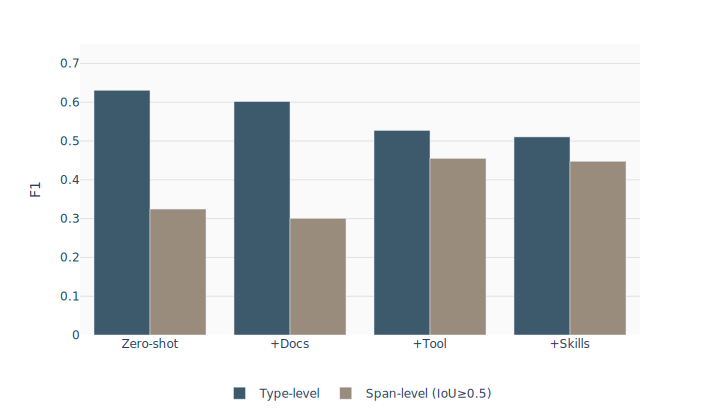

In [6]:
# Post-alignment F1 by condition under each metric: zero-shot leads on type, the detector leads on span.
fig = go.Figure()
fig.add_bar(name="Type-level", x=[CLABEL[c] for c in CONDITIONS], y=[mean_f1(main, c, norm, False) for c in CONDITIONS], marker_color=TEAL)
fig.add_bar(name="Span-level (IoU≥0.5)", x=[CLABEL[c] for c in CONDITIONS], y=[mean_f1(main, c, norm, True) for c in CONDITIONS], marker_color=TAUPE)
style(fig, "", barmode="group",
      yaxis=dict(title="F1", range=[0, 0.75], gridcolor="#e0e0e0"))

fig.show(renderer="svg"); fig.write_image("fig_dual_metric_main.pdf")

### Type→span inversion (slopegraph, all configurations)

Every configuration as a line from its type-level F1 to its span-level F1, one color per configuration (the notebook-03 condition palette, extended for the baselines and the standalone library). The parametric/model-native conditions start highest on type and fall on span; the tool-augmented conditions do the reverse, so the lines **cross** — that is the ranking inversion. The standalone library (dotted) sits low on both metrics.

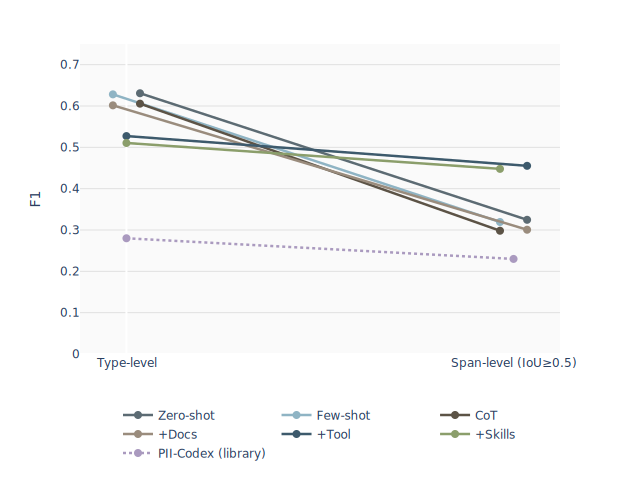

In [7]:
# Slopegraph across all configurations: type-level -> span-level F1, one color per config
# (nb03 condition palette: slate / taupe / teal / sage, extended for few-shot, CoT, library).
_bl = load_run("baselines")
def _af1(recs, cond, span):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, span) for r in recs if r["condition"] == cond]
    return (sum(v) / len(v)) if v else float("nan")

def _slope_x_jitter(values, width=0.07, tol=0.012):
    """Spread tied endpoints horizontally so overlapping markers remain visible."""
    n = len(values)
    offsets = [0.0] * n
    order = sorted(range(n), key=lambda i: values[i])
    i = 0
    while i < n:
        j = i + 1
        while j < n and abs(values[order[j]] - values[order[i]]) <= tol:
            j += 1
        group = order[i:j]
        if len(group) > 1:
            step = width / (len(group) - 1)
            for k, idx in enumerate(group):
                offsets[idx] = -width / 2 + k * step
        i = j
    return offsets

try:
    det_t, det_s = base["type-only"], base["span-IoU"]
except NameError:
    det_t, det_s = 0.28, 0.23
configs = [("Zero-shot", main, "zero_shot", "#5C6B73", "solid")]
if _bl:
    configs += [("Few-shot", _bl, "few_shot", "#8FB4C4", "solid"),
                ("CoT", _bl, "cot", "#5C5346", "solid")]
configs += [("+Docs", main, "with_docs", "#9A8C7D", "solid"),
            ("+Tool", main, "with_tools", "#3D5A6C", "solid"),
            ("+Skills", main, "with_skills", "#8B9E6B", "solid"),
            ("PII-Codex (library)", None, None, "#AA9ABF", "dot")]
xcats = ["Type-level", "Span-level (IoU≥0.5)"]
series = []
for name, recs, cond, col, dash in configs:
    yt, ys = (det_t, det_s) if recs is None else (_af1(recs, cond, False), _af1(recs, cond, True))
    series.append((name, yt, ys, col, dash))
jx_type = _slope_x_jitter([yt for _, yt, _, _, _ in series])
jx_span = _slope_x_jitter([ys for _, _, ys, _, _ in series])
fig = go.Figure()
for i, (name, yt, ys, col, dash) in enumerate(series):
    fig.add_scatter(x=[0 + jx_type[i], 1 + jx_span[i]], y=[yt, ys], mode="lines+markers", name=name,
                    line=dict(color=col, width=2.5, dash=dash), marker=dict(size=8, color=col))
style(fig, "", h=480, w=640,
      xaxis=dict(showgrid=False, tickmode="array", tickvals=[0, 1], ticktext=xcats, range=[-0.12, 1.12]),
      yaxis=dict(title="F1", range=[0, 0.75], gridcolor="#e0e0e0"))
fig.show(renderer="svg"); fig.write_image("fig_dual_metric_slope.pdf")

## 5. Per-type recall (tool/skill), before vs after alignment

Computes tool/skill recall per PII type, before vs after alignment, separating the collapses that were label-schema artifacts (DATE_TIME, LOCATION) from the genuine detector limit (HEALTH_INSURANCE_ID).

In [8]:
def type_recall(nf, group, conds, min_n=50):
    hit, tot = defaultdict(int), defaultdict(int)
    
    for r in main:
        if r["condition"] not in conds: continue
        gt = r["ground_truth"] or []; used = set()
        
        for p in [p for p in (r["predictions"] or []) if isinstance(p, dict) and "type" in p]:
            pt = nf(p.get("type", ""))
            
            for i, t in enumerate(gt):
                if i in used or pt != nf(t.get("type", "")): continue
                used.add(i); break
        
        for i, t in enumerate(gt):
            k = group(t.get("type", "")); tot[k] += 1
            if i in used: hit[k] += 1
    
    return {k: hit[k]/tot[k] for k in tot if tot[k] >= min_n}

aug = ["with_tools", "with_skills"]
b, a = type_recall(norm_pre, norm, aug), type_recall(norm, norm, aug)
df_type = pd.DataFrame([{"type": t, "before": round(b.get(t, 0), 3), "after": round(a.get(t, 0), 3),
                         "Δ": round(a.get(t, 0) - b.get(t, 0), 3)}
                        for t in sorted(set(b) | set(a), key=lambda t: -a.get(t, 0))])

df_type

,type,before,after,Δ
0,EMAIL_ADDRESS,0.968,0.968,0.000
1,MAC_ADDRESS,0.955,0.955,0.000
2,IP_ADDRESS,0.939,0.939,0.000
3,URL,0.777,0.777,0.000
4,US_DRIVERS_LICENSE_NUMBER,0.760,0.760,0.000
5,DATE_TIME,0.217,0.690,0.473
6,PHONE_NUMBER,0.640,0.640,0.000
7,US_PASSPORT_NUMBER,0.635,0.635,0.000
8,US_SOCIAL_SECURITY_NUMBER,0.553,0.553,0.000
9,US_BANK_ACCOUNT_NUMBER,0.477,0.477,0.000


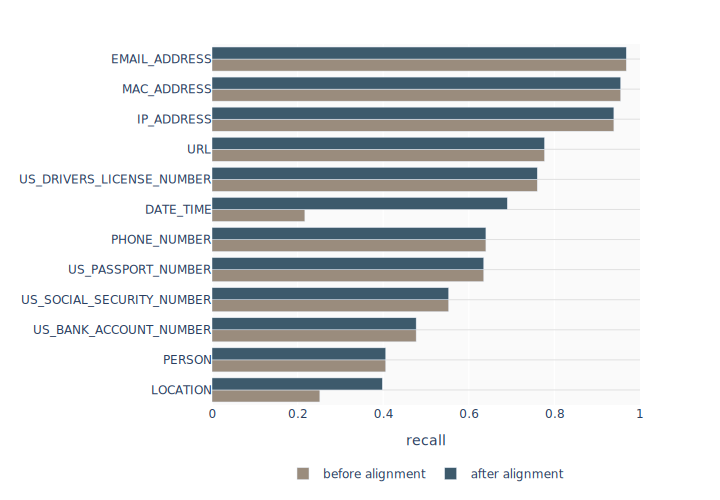

In [9]:
top = df_type.head(12).iloc[::-1]

fig = go.Figure()
fig.add_bar(name="before alignment", y=top["type"], x=top["before"], orientation="h", marker_color=TAUPE)
fig.add_bar(name="after alignment", y=top["type"], x=top["after"], orientation="h", marker_color=TEAL)
style(fig, "", h=500,
      barmode="group", xaxis=dict(title="recall", range=[0, 1]))

fig.show(renderer="svg"); fig.write_image("fig_type_recall_alignment.pdf")

## 6. Detector over-prediction

Tallies how often the detector predicts each type versus its true frequency, surfacing the over-generation (drivers-license, bank-account, URL) that drives the precision collapse under tool use.

In [10]:
pv, sup, seen = Counter(), Counter(), set()
for r in main:
    if r["condition"] in aug:
        for p in (r["predictions"] or []):
            if isinstance(p, dict) and "type" in p: pv[norm(p.get("type", ""))] += 1
    if r["sample_id"] not in seen:
        seen.add(r["sample_id"])
        for t in (r["ground_truth"] or []): sup[norm(t.get("type", ""))] += 1
df_over = pd.DataFrame([{"type": k, "predicted": n, "support": sup.get(k, 0),
                         "ratio": round(n / sup[k], 1) if sup.get(k) else float("inf")}
                        for k, n in pv.most_common()]).head(12)

df_over

,type,predicted,support,ratio
0,DATE_TIME,16097,2103,7.7
1,US_DRIVERS_LICENSE_NUMBER,12150,383,31.7
2,PERSON,10435,2324,4.5
3,LOCATION,7461,1930,3.9
4,PHONE_NUMBER,5771,566,10.2
5,EMAIL_ADDRESS,5080,632,8.0
6,US_SOCIAL_SECURITY_NUMBER,4863,632,7.7
7,URL,4501,92,48.9
8,IP_ADDRESS,4051,515,7.9
9,US_BANK_ACCOUNT_NUMBER,3421,44,77.8


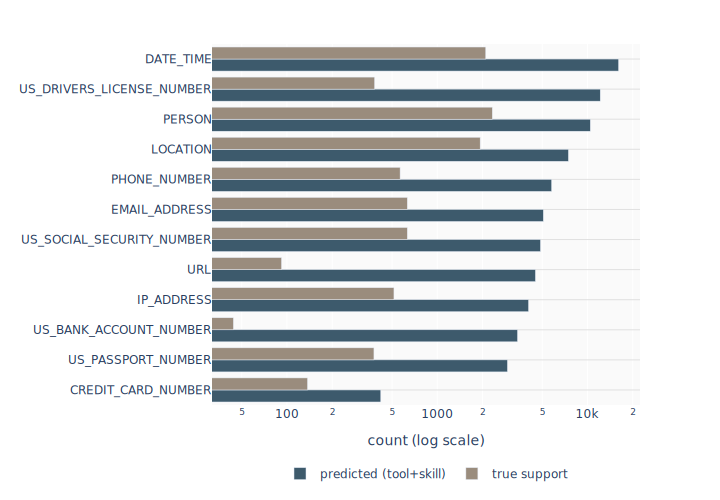

In [11]:
o = df_over.iloc[::-1]

fig = go.Figure()
fig.add_bar(name="predicted (tool+skill)", y=o["type"], x=o["predicted"], orientation="h", marker_color=TEAL)
fig.add_bar(name="true support", y=o["type"], x=o["support"], orientation="h", marker_color=TAUPE)

style(fig, "", h=500,
      barmode="group", xaxis=dict(title="count (log scale)", type="log"))

fig.show(renderer="svg"); fig.write_image("fig_overprediction.pdf")

## 7. Scaling — Qwen2.5-14B

Loads the 14B run and slots it into the dual-metric table beside the 7–9B models, showing the augmentation pattern is unchanged with scale.

,set,Zero-shot,+Docs,+Tool,+Skills
0,7–9B avg,0.631,0.602,0.527,0.511
1,Qwen 14B,0.605,0.632,0.520,0.521


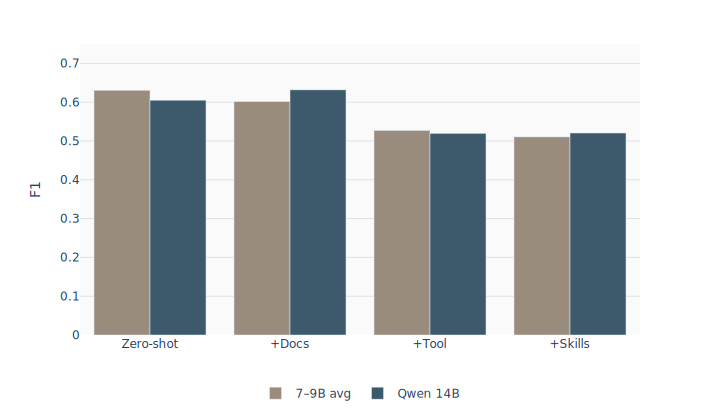

In [12]:
scaling = load_run("scaling")
if not scaling:
    print("scaling run not found")
else:
    sevenb = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    
    def cond_means(recs, models, span=False):
        return {c: statistics.mean([f1(r["predictions"] or [], r["ground_truth"] or [], norm, span)
                                    for r in recs if r["condition"] == c and r["model"] in models]) for c in CONDITIONS}
    
    avg = cond_means(main, sevenb); q14 = cond_means(scaling, ["qwen2_14b"])
    display(pd.DataFrame([{"set": "7–9B avg", **{CLABEL[c]: round(avg[c], 3) for c in CONDITIONS}},
                          {"set": "Qwen 14B", **{CLABEL[c]: round(q14[c], 3) for c in CONDITIONS}}]))
    fig = go.Figure()
    fig.add_bar(name="7–9B avg", x=[CLABEL[c] for c in CONDITIONS], y=[avg[c] for c in CONDITIONS], marker_color=TAUPE)
    fig.add_bar(name="Qwen 14B", x=[CLABEL[c] for c in CONDITIONS], y=[q14[c] for c in CONDITIONS], marker_color=TEAL)
    style(fig, "", barmode="group",
          yaxis=dict(title="F1", range=[0, 0.75], gridcolor="#e0e0e0"))
    
    fig.show(renderer="svg"); fig.write_image("fig_scaling_14b.pdf")

## 8. Full precision vs 4-bit

Four models re-run at fp16/bf16 on a 300-sample subset, compared **paired** against 4-bit on the identical IDs. Tests whether quantization drives the effect.

,model,4-bit,fp16,Δ,95% CI
0,Gemma 2 9B,0.567,0.574,0.007,±0.008
1,Llama 3.1 8B,0.562,0.590,0.028,±0.016
2,Mistral 7B,0.530,0.527,-0.003,±0.012
3,Qwen 2.5 7B,0.565,0.557,-0.008,±0.012


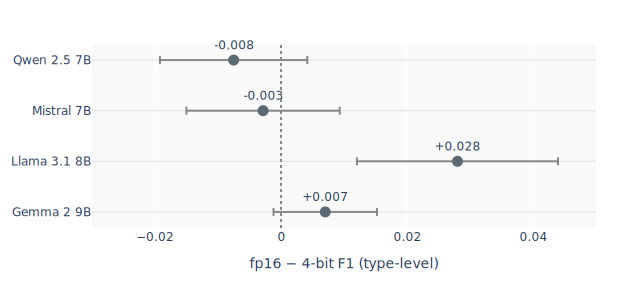

In [13]:
fp16 = load_run("fp16")
if not fp16:
    print("fp16 run not found")
else:
    main_ix = {(r["model"], r["condition"], r["sample_id"]): r for r in main}
    models = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    MLABEL = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B", "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}
    
    rows, deltas, cis = [], [], []
    for m in models:
        d = []
        q4 = qf = 0; n = 0
        for x in fp16:
            if x["model"] != m: continue
            mr = main_ix.get((m, x["condition"], x["sample_id"]))
            if mr is None: continue
            ff = f1(x["predictions"] or [], x["ground_truth"] or [], norm, False)
            qq = f1(mr["predictions"] or [], mr["ground_truth"] or [], norm, False)
            d.append(ff - qq); qf += ff; q4 += qq; n += 1
        md_, sd = statistics.mean(d), statistics.pstdev(d)
        ci = 1.96 * sd / math.sqrt(len(d))
        rows.append({"model": MLABEL[m], "4-bit": round(q4/n, 3), "fp16": round(qf/n, 3), "Δ": round(md_, 3), "95% CI": f"±{ci:.3f}"})
        deltas.append(md_); cis.append(ci)
    
    display(pd.DataFrame(rows))
    pad = 0.006
    x_lo = math.floor((min(d - c for d, c in zip(deltas, cis)) - pad) / 0.005) * 0.005
    x_hi = math.ceil((max(d + c for d, c in zip(deltas, cis)) + pad) / 0.005) * 0.005
    fig = go.Figure(go.Scatter(y=[MLABEL[m] for m in models], x=deltas, mode="markers+text",
                           text=[f"{d:+.3f}" for d in deltas], textposition="top center",
                           error_x=dict(type="data", array=cis, color="#888"),
                           marker=dict(color=INK, size=11), cliponaxis=False))
    
    fig.add_vline(x=0, line_dash="dot", line_color="#888")
    style(fig, "", h=300, w=620,
          margin=dict(t=44, b=72, r=24, l=92),
          xaxis=dict(title="fp16 − 4-bit F1 (type-level)", range=[x_lo, x_hi], zeroline=False))
    
    fig.update_layout(showlegend=False)
    fig.show(renderer="svg"); fig.write_image("fig_fp16_vs_4bit.pdf")

## 9. Significance, reliability, and determinism

Paired t-test and Cohen's d on post-alignment type-only F1 (each condition vs zero-shot); tool-call execution rate and turn counts; and the determinism that makes a seed sweep unnecessary.

Decoding is greedy (`do_sample=False`; MLX argmax), so outputs are deterministic across seeds — run-to-run variance is nil and the seed governs only the fixed benchmark subsample.

In [14]:
from scipy import stats as _st
def _ps(m, c):
    return {r["sample_id"]: f1(r["predictions"] or [], r["ground_truth"] or [], norm, False)
            for r in main if r["model"] == m and r["condition"] == c}

rows = []

for m in ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]:
    zs = _ps(m, "zero_shot")
    for c in ["with_docs", "with_tools", "with_skills"]:
        cc = _ps(m, c); ids = sorted(set(zs) & set(cc))
        a, b = [cc[i] for i in ids], [zs[i] for i in ids]
        d = [x - y for x, y in zip(a, b)]
        t, p = _st.ttest_rel(a, b)
        rows.append({"model": m, "vs ZS": CLABEL[c], "ΔF1": round(statistics.mean(d), 3),
                     "Cohen d": round(statistics.mean(d) / (statistics.pstdev(d) or 1e-9), 2),
                     "p": f"{p:.1e}"})

df_sig = pd.DataFrame(rows)
df_sig

,model,vs ZS,ΔF1,Cohen d,p
0,gemma2_9b,+Docs,0.011,0.04,7.1e-02
1,gemma2_9b,+Tool,-0.099,-0.27,6.1e-32
2,gemma2_9b,+Skills,-0.098,-0.27,1.8e-31
3,llama3_8b,+Docs,-0.149,-0.37,2.1e-57
4,llama3_8b,+Tool,-0.108,-0.32,4.7e-44
5,llama3_8b,+Skills,-0.172,-0.49,5.3e-95
6,mistral_7b,+Docs,0.009,0.03,1.8e-01
7,mistral_7b,+Tool,-0.056,-0.16,2.0e-12
8,mistral_7b,+Skills,-0.056,-0.16,1.3e-12
9,qwen2_7b,+Docs,0.012,0.04,9.2e-02


In [15]:
rows = []
for c in ["with_tools", "with_skills"]:
    for m in ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]:
        rs = [r for r in main if r["model"] == m and r["condition"] == c]
        fired = sum(1 for r in rs if r.get("tool_executed"))
        turns = [r.get("conversation_turns") or 1 for r in rs]
        rows.append({"condition": CLABEL[c], "model": m, "tool fired": f"{fired}/{len(rs)}",
                     "%": round(100 * fired / len(rs), 1), "mean turns": round(statistics.mean(turns), 2)})

df_reliab = pd.DataFrame(rows)
df_reliab

,condition,model,tool fired,%,mean turns
0,+Tool,gemma2_9b,2000/2000,100.0,2.00
1,+Tool,llama3_8b,2000/2000,100.0,2.01
2,+Tool,mistral_7b,1999/2000,100.0,2.00
3,+Tool,qwen2_7b,2000/2000,100.0,2.01
4,+Skills,gemma2_9b,2000/2000,100.0,3.99
5,+Skills,llama3_8b,2000/2000,100.0,3.95
6,+Skills,mistral_7b,1999/2000,100.0,2.02
7,+Skills,qwen2_7b,2000/2000,100.0,2.38


## 10. Specialized-detector baseline

PII-Codex/Presidio run standalone on the 2,000 texts (no LLM), scored with the same alignment — the prior-work detector row to judge the four configurations against. Requires `data/samples_main.json` (`make rr-samples`) and the `pii_codex` package. Running it also writes the detector predictions to `results/past_runs/detector/`, so the baseline is reproducible via `load_run("detector")` without re-running PII-Codex.


In [16]:
# PII-Codex/Presidio standalone on the 2,000 texts (no LLM), scored with the same alignment.
import sys
sys.path.insert(0, str(REPO_ROOT / "lib"))
samples = json.load(open(REPO_ROOT / "data" / "samples_main.json"))

try:
    from pii_codex.services.analysis_service import PIIAnalysisService
    from ablation_harness.tools.registry import ToolRegistry, PiiCodexTool
    
    reg = ToolRegistry(); reg.register(PiiCodexTool(PIIAnalysisService()))
    det = []
    
    for s in samples:
        res = reg.execute("analyze_pii", text=s["text"])
        preds = res.get("detections", []) if isinstance(res, dict) else (res or [])
        gt = s.get("ground_truth"); gt = json.loads(gt) if isinstance(gt, str) else (gt or [])
        det.append({"predictions": preds, "ground_truth": gt})
    base = {lbl: round(sum(f1(r["predictions"], r["ground_truth"], norm, span) for r in det) / len(det), 3)
            for span, lbl in [(False, "type-only"), (True, "span-IoU")]}
    
    print("Specialized detector (PII-Codex standalone) F1:", base)
    print("Compare against the configurations in section 4.")
    
    # Persist as a run file so the detector baseline is reproducible from an artifact (load_run("detector")).
    det_dir = REPO_ROOT / "results" / "past_runs" / "detector"
    det_dir.mkdir(parents=True, exist_ok=True)
    
    records = [
        {"sample_id": s["id"], "source": s.get("source", ""), "model": "pii_codex",
         "condition": "detector", "predictions": r["predictions"], "ground_truth": r["ground_truth"],
         "tool_executed": True}
        for s, r in zip(samples, det)
    ]
    json.dump(records, open(det_dir / "experiment_results.json", "w"))
    
    print(f"Saved {len(records)} detector rows -> {det_dir / 'experiment_results.json'}")
except ImportError as e:
    print(f"pii_codex not installed — run `make install`. ({e})")
except FileNotFoundError:
    print("data/samples_main.json missing — run `make rr-samples` first.")

Specialized detector (PII-Codex standalone) F1: {'type-only': 0.276, 'span-IoU': 0.227}
Compare against the configurations in section 4.
Saved 2000 detector rows -> /Users/erosado/work/academia/pii-codex-skills-ablation-study/results/past_runs/detector/experiment_results.json


## 11. Few-shot and chain-of-thought baselines

Loads the `baselines` run (conditions `few_shot`, `cot`; four models, full 2,000) and scores them under the symmetric alignment next to zero-shot. Checks whether the cheapest prompt-only parametric augmentations behave differently from tool/skill scaffolding. No-ops until `make rr-baselines` has been run.

In [17]:
baselines = load_run("baselines")
if not baselines:
    print("baselines run not found — run `make rr-baselines`, then re-run this cell.")
else:
    models = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
    MLAB = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B", "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}
    
    def mc(recs, m, c, span):
        v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, span)
             for r in recs if r["model"] == m and r["condition"] == c]
        return sum(v) / len(v) if v else float("nan")
    
    rows = []
    for m in models:
        rows.append({"model": MLAB[m],
                     "ZS": round(mc(main, m, "zero_shot", False), 3),
                     "few-shot": round(mc(baselines, m, "few_shot", False), 3),
                     "CoT": round(mc(baselines, m, "cot", False), 3),
                     "ZS (span)": round(mc(main, m, "zero_shot", True), 3),
                     "few-shot (span)": round(mc(baselines, m, "few_shot", True), 3),
                     "CoT (span)": round(mc(baselines, m, "cot", True), 3)})
    display(pd.DataFrame(rows))

    print("\n4-model averages (paste into Results / abstract):")

    for span, lbl in [(False, "type-only"), (True, "span")]:
        zs = sum(mc(main, m, "zero_shot", span) for m in models) / 4
        fs = sum(mc(baselines, m, "few_shot", span) for m in models) / 4
        ct = sum(mc(baselines, m, "cot", span) for m in models) / 4
        print(f"  {lbl:9}: ZS {zs:.3f} | few-shot {fs:.3f} | CoT {ct:.3f}")

,model,ZS,few-shot,CoT,ZS (span),few-shot (span),CoT (span)
0,Gemma 2 9B,0.624,0.647,0.674,0.328,0.338,0.333
1,Llama 3.1 8B,0.675,0.610,0.573,0.338,0.303,0.274
2,Mistral 7B,0.584,0.616,0.566,0.305,0.312,0.295
3,Qwen 2.5 7B,0.640,0.640,0.609,0.328,0.324,0.291



4-model averages (paste into Results / abstract):
  type-only: ZS 0.631 | few-shot 0.628 | CoT 0.606
  span     : ZS 0.325 | few-shot 0.319 | CoT 0.298


## 12. All configurations at a glance

One bar per configuration (type-level F1, four-model average), grouped by family. Shows the parametric configurations (zero-shot, few-shot, CoT, +Docs) clustering near the top, the tool-augmented conditions dropping below the zero-shot reference line, and the standalone library far beneath both.

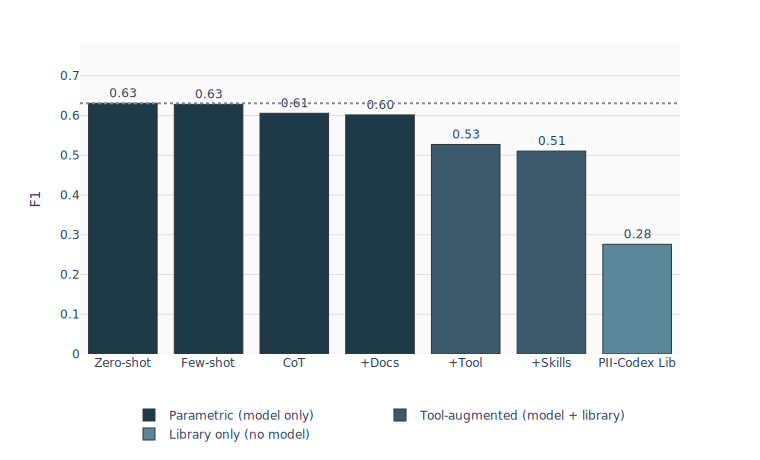

In [18]:
# Type-level F1 (4-model average) for every configuration, grouped by family.
def _avg(recs, cond):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, False)
         for r in recs if r["condition"] == cond]
    return sum(v) / len(v) if v else None

bars = [
    ("Zero-shot", _avg(main, "zero_shot"),               "Parametric (model only)"),
    ("Few-shot",  _avg(baselines, "few_shot") if baselines else None, "Parametric (model only)"),
    ("CoT",       _avg(baselines, "cot") if baselines else None,      "Parametric (model only)"),
    ("+Docs",     _avg(main, "with_docs"),               "Parametric (model only)"),
    ("+Tool",     _avg(main, "with_tools"),              "Tool-augmented (model + library)"),
    ("+Skills",   _avg(main, "with_skills"),             "Tool-augmented (model + library)"),
]
# detector-only value from Section 10 if available, else the recorded result
try:
    bars.append(("PII-Codex Lib", base["type-only"], "Library only (no model)"))
except NameError:
    bars.append(("PII-Codex Lib", 0.28, "Library only (no model)"))

bars = [b for b in bars if b[1] is not None]
bars.sort(key=lambda b: -b[1])
order = [b[0] for b in bars]
fam_color = {
    "Parametric (model only)":          "#1E3A47",  # very dark teal (best)
    "Tool-augmented (model + library)": "#3D5A6C",  # deep teal
    "Library only (no model)":          "#5A8799",  # medium teal (lowest)
}
zs = next(b[1] for b in bars if b[0] == "Zero-shot")

fig = go.Figure()
for fam, col in fam_color.items():
    xs = [b[0] for b in bars if b[2] == fam]
    ys = [b[1] for b in bars if b[2] == fam]
    fig.add_bar(name=fam, x=xs, y=ys, marker_color=col, marker_line=dict(width=1, color="#2D353B"),
                text=[f"{y:.2f}" for y in ys], textposition="outside", cliponaxis=False)
fig.update_xaxes(categoryorder="array", categoryarray=order)
fig.add_hline(y=zs, line_dash="dot", line_color="#888")
style(fig, "", h=460, w=760,
      barmode="group", yaxis=dict(title="F1", range=[0, 0.78], gridcolor="#e0e0e0"))
fig.show(renderer="svg"); fig.write_image("fig_all_conditions.pdf")

## 13. Appendix C statistics: parametric baselines vs zero-shot

Per-model paired comparison (paired t, p, Cohen's d, and % of samples improved) of the few-shot and
chain-of-thought baselines against zero-shot at the type level, computed the same way as the main
statistics table (`tab:app_stats_full`). Prints a DataFrame and LaTeX-ready rows for Appendix C.
No-ops until `make rr-baselines` has been run.

In [19]:
# Paired stats (t, p, Cohen's d, % improved) for the parametric baselines vs zero-shot, type level.
# d = mean / population-stdev of the paired per-sample deltas, matching tab:app_stats_full.
baselines = load_run("baselines")

if not baselines:
    print("baselines run not found \u2014 run `make rr-baselines`, then re-run this cell.")
else:
    try:
        from scipy import stats as _ss
        def _pair_t(a, b):
            return _ss.ttest_rel(a, b)
    except Exception:
        def _pair_t(a, b):
            d = [x - y for x, y in zip(a, b)]
            t = statistics.mean(d) / (statistics.stdev(d) / math.sqrt(len(d)))
            return t, math.erfc(abs(t) / math.sqrt(2))   # normal approx (n is large)

    MODELS = ["llama3_8b", "mistral_7b", "qwen2_7b", "gemma2_9b"]
    LAB = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B",
           "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}

    def _f1_by_id(recs, m, c):
        return {r["sample_id"]: f1(r["predictions"] or [], r["ground_truth"] or [], norm, False)
                for r in recs if r["model"] == m and r["condition"] == c}

    rows, tex = [], []

    for m in MODELS:
        zs = _f1_by_id(main, m, "zero_shot")

        for cond, lbl in [("few_shot", "Few-shot vs ZS"), ("cot", "CoT vs ZS")]:
            cc = _f1_by_id(baselines, m, cond)
            ids = [i for i in cc if i in zs]
            a, b = [cc[i] for i in ids], [zs[i] for i in ids]
            delta = [x - y for x, y in zip(a, b)]

            d = statistics.mean(delta) / statistics.pstdev(delta)
            t, p = _pair_t(a, b)
            pct = 100 * sum(x > 0 for x in delta) / len(delta)

            rows.append({"model": LAB[m], "comparison": lbl, "t": round(float(t), 2),
                         "p": "<0.0001" if p < 1e-4 else round(float(p), 4),
                         "d": round(d, 3), "% improved": round(pct, 1)})

            mtex = m.replace("_", "\\_")
            ptex = "$<0.0001$" if p < 1e-4 else f"${float(p):.3f}$"
            tex.append(f"{mtex} & {lbl} & ${t:+.2f}$ & {ptex} & ${d:+.3f}$ & {pct:.1f}\\% \\\\")

    display(pd.DataFrame(rows))
    print("\n% LaTeX rows for Appendix C (few-shot / CoT vs ZS):")
    print("\n".join(tex))

,model,comparison,t,p,d,% improved
0,Llama 3.1 8B,Few-shot vs ZS,-8.91,<0.0001,-0.199,27.0
1,Llama 3.1 8B,CoT vs ZS,-13.29,<0.0001,-0.297,24.1
2,Mistral 7B,Few-shot vs ZS,4.61,<0.0001,0.103,41.2
3,Mistral 7B,CoT vs ZS,-2.73,0.0063,-0.061,29.9
4,Qwen 2.5 7B,Few-shot vs ZS,-0.09,0.9293,-0.002,31.4
5,Qwen 2.5 7B,CoT vs ZS,-4.30,<0.0001,-0.096,29.6
6,Gemma 2 9B,Few-shot vs ZS,4.26,<0.0001,0.095,31.2
7,Gemma 2 9B,CoT vs ZS,8.52,<0.0001,0.191,36.5



% LaTeX rows for Appendix C (few-shot / CoT vs ZS):
llama3\_8b & Few-shot vs ZS & $-8.91$ & $<0.0001$ & $-0.199$ & 27.0\% \\
llama3\_8b & CoT vs ZS & $-13.29$ & $<0.0001$ & $-0.297$ & 24.1\% \\
mistral\_7b & Few-shot vs ZS & $+4.61$ & $<0.0001$ & $+0.103$ & 41.2\% \\
mistral\_7b & CoT vs ZS & $-2.73$ & $0.006$ & $-0.061$ & 29.9\% \\
qwen2\_7b & Few-shot vs ZS & $-0.09$ & $0.929$ & $-0.002$ & 31.4\% \\
qwen2\_7b & CoT vs ZS & $-4.30$ & $<0.0001$ & $-0.096$ & 29.6\% \\
gemma2\_9b & Few-shot vs ZS & $+4.26$ & $<0.0001$ & $+0.095$ & 31.2\% \\
gemma2\_9b & CoT vs ZS & $+8.52$ & $<0.0001$ & $+0.191$ & 36.5\% \\


## 14. Appendix D recall: every condition and baseline by PII type

Type-level recall by PII type for all six configurations (zero-shot, +Docs, +Tool, +Skills, few-shot,
chain-of-thought), per model, across the most frequent types. Computed under one consistent method so the
baselines sit alongside the four primary conditions in the per-type recall appendix.
No-ops until `make rr-baselines` has been run.

In [20]:
# Type-level recall by PII type for all six configurations, per model (one consistent computation).
baselines = load_run("baselines")

if not baselines:
    print("baselines run not found \u2014 run `make rr-baselines`, then re-run this cell.")
else:
    MODELS = ["llama3_8b", "mistral_7b", "qwen2_7b", "gemma2_9b"]
    LAB = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B",
           "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}

    TYPES = ["DATE_TIME", "EMAIL_ADDRESS", "HEALTH_INSURANCE_ID", "IP_ADDRESS", "LOCATION",
             "PERSON", "PHONE_NUMBER", "US_DRIVERS_LICENSE_NUMBER", "US_PASSPORT_NUMBER",
             "US_SOCIAL_SECURITY_NUMBER"]

    SRC = [("ZS", main, "zero_shot"), ("+Docs", main, "with_docs"),
           ("+Tool", main, "with_tools"), ("+Skills", main, "with_skills"),
           ("few-shot", baselines, "few_shot"), ("CoT", baselines, "cot")]

    def _recall(recs, m, c, canon):
        tp = fn = 0
        for r in recs:
            if r["model"] != m or r["condition"] != c:
                continue
            gt = [norm(t["type"]) for t in (r["ground_truth"] or []) if isinstance(t, dict) and "type" in t]
            pr = [norm(x["type"]) for x in (r["predictions"] or []) if isinstance(x, dict) and "type" in x]
            ng = gt.count(canon)
            if ng == 0:
                continue
            tp += min(ng, pr.count(canon))
            fn += ng - min(ng, pr.count(canon))
        return tp / (tp + fn) if (tp + fn) else float("nan")

    rows = []

    for m in MODELS:
        for canon in TYPES:
            row = {"model": LAB[m], "PII type": canon}
            for lbl, recs, c in SRC:
                v = _recall(recs, m, c, canon)
                row[lbl] = round(v, 2) if v == v else None
            rows.append(row)

    display(pd.DataFrame(rows))

,model,PII type,ZS,+Docs,+Tool,+Skills,few-shot,CoT
0,Llama 3.1 8B,DATE_TIME,0.70,0.58,0.75,0.73,0.75,0.73
1,Llama 3.1 8B,EMAIL_ADDRESS,0.94,0.77,0.97,0.94,0.88,0.76
2,Llama 3.1 8B,HEALTH_INSURANCE_ID,0.73,0.17,0.08,0.01,0.52,0.36
3,Llama 3.1 8B,IP_ADDRESS,0.92,0.56,0.96,0.90,0.83,0.69
4,Llama 3.1 8B,LOCATION,0.53,0.46,0.47,0.41,0.60,0.56
5,Llama 3.1 8B,PERSON,0.65,0.47,0.48,0.40,0.63,0.67
6,Llama 3.1 8B,PHONE_NUMBER,0.85,0.72,0.72,0.63,0.82,0.62
7,Llama 3.1 8B,US_DRIVERS_LICENSE_NUMBER,0.48,0.13,0.81,0.80,0.43,0.31
8,Llama 3.1 8B,US_PASSPORT_NUMBER,0.64,0.41,0.72,0.67,0.52,0.44
9,Llama 3.1 8B,US_SOCIAL_SECURITY_NUMBER,0.76,0.62,0.63,0.56,0.60,0.52


### Recall by PII type and configuration (heatmap)

Matrix form of the per-type recall data (4-model average, symmetric alignment): rows are PII types, columns are configurations, cell shade is recall. Structured identifiers brighten under +Tool/+Skills, `DATE_TIME`/`LOCATION` recover, and `HEALTH_INSURANCE_ID` stays dark under the tool conditions (the genuine detector gap).

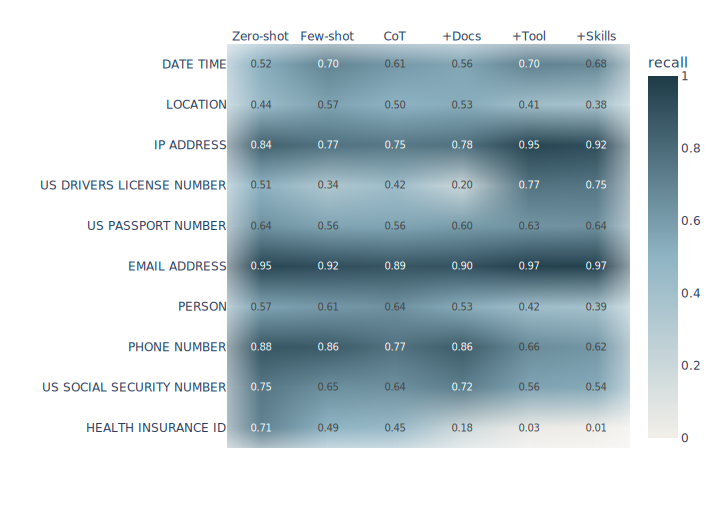

In [21]:
# Heatmap: 4-model-average type-level recall by PII type x configuration (matrix view of the
# original "recall by PII type and condition" figure, under symmetric alignment).
_bl = load_run("baselines")
MODELS = ["gemma2_9b", "llama3_8b", "mistral_7b", "qwen2_7b"]
TYPES = ["DATE_TIME", "LOCATION", "IP_ADDRESS", "US_DRIVERS_LICENSE_NUMBER", "US_PASSPORT_NUMBER",
         "EMAIL_ADDRESS", "PERSON", "PHONE_NUMBER", "US_SOCIAL_SECURITY_NUMBER", "HEALTH_INSURANCE_ID"]
SRC = [("Zero-shot", main, "zero_shot")]
if _bl:
    SRC += [("Few-shot", _bl, "few_shot"), ("CoT", _bl, "cot")]
SRC += [("+Docs", main, "with_docs"), ("+Tool", main, "with_tools"), ("+Skills", main, "with_skills")]

def _recall(recs, m, c, canon):
    tp = fn = 0
    for r in recs:
        if r["model"] != m or r["condition"] != c:
            continue
        gt = [norm(t["type"]) for t in (r["ground_truth"] or []) if isinstance(t, dict) and "type" in t]
        pr = [norm(x["type"]) for x in (r["predictions"] or []) if isinstance(x, dict) and "type" in x]
        ng = gt.count(canon)
        if ng == 0:
            continue
        tp += min(ng, pr.count(canon)); fn += ng - min(ng, pr.count(canon))
    return tp / (tp + fn) if (tp + fn) else float("nan")

def _avg(recs, c, canon):
    vals = [_recall(recs, m, c, canon) for m in MODELS]
    vals = [v for v in vals if v == v]
    return sum(vals) / len(vals) if vals else float("nan")

conds = [lbl for lbl, _, _ in SRC]
z = [[_avg(recs, c, canon) for (_, recs, c) in SRC] for canon in TYPES]
txt = [[f"{v:.2f}" if v == v else "" for v in row] for row in z]
fig = go.Figure(go.Heatmap(
    z=z, x=conds, y=[t.replace("_", " ") for t in TYPES], text=txt,
    texttemplate="%{text}", textfont=dict(size=10), zmin=0, zmax=1,
    colorscale=[[0, "#F2EFE9"], [0.5, "#8FB4C4"], [1, "#1E3A47"]],
    colorbar=dict(title="recall")))
    
fig.update_yaxes(autorange="reversed")
style(fig, "", h=520, w=720, xaxis=dict(side="top"), yaxis=dict(title=""))
fig.show(renderer="svg"); fig.write_image("fig_recall_heatmap.pdf")

## 15. Appendix F: skill-viewed subgroup (group sizes and mean F1)

For the +Skills condition, splits runs by whether the model read the Skill document (the `skill_viewed`
flag) and compares group sizes and mean type-level F1 between viewed and not-viewed, under the symmetric
alignment. Models with a 100% view rate have no not-viewed group (difference is n/a). Backs Appendix F.

In [22]:
# Skill-viewed subgroup for +Skills: group sizes, view rate, and mean type-level F1 (viewed vs not-viewed).
MODELS = ["mistral_7b", "qwen2_7b", "llama3_8b", "gemma2_9b"]
LAB = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B",
       "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}

def _mean_f1(rs):
    v = [f1(r["predictions"] or [], r["ground_truth"] or [], norm, False) for r in rs]
    return sum(v) / len(v) if v else float("nan")

rows = []

for m in MODELS:
    recs = [r for r in main if r["model"] == m and r["condition"] == "with_skills"]
    vw = [r for r in recs if r.get("skill_viewed")]
    nv = [r for r in recs if not r.get("skill_viewed")]

    fv, fn = _mean_f1(vw), _mean_f1(nv)

    rows.append({"model": LAB[m],
                 "viewed n": len(vw),
                 "not-viewed n": len(nv),
                 "view rate": f"{100 * len(vw) / len(recs):.1f}%",
                 "F1 viewed": round(fv, 4),
                 "F1 not-viewed": (round(fn, 4) if nv else None),
                 "mean F1 diff (viewed - not)": (round(fv - fn, 4) if nv else None)})

display(pd.DataFrame(rows))

,model,viewed n,not-viewed n,view rate,F1 viewed,F1 not-viewed,mean F1 diff (viewed - not)
0,Mistral 7B,948,1052,47.4%,0.5334,0.5225,0.0109
1,Qwen 2.5 7B,341,1659,17.1%,0.4829,0.4848,-0.0019
2,Llama 3.1 8B,2000,0,100.0%,0.5039,NaN,NaN
3,Gemma 2 9B,2000,0,100.0%,0.5261,NaN,NaN


## 16. Construct validity: what span-level scoring actually measures

Span-level scoring conflates *type recovery*, *localization*, and *exact offset generation*. The strata below separate those; only `ai4privacy` ships character spans, so on the other two sources the span metric silently collapses into the type metric.


In [23]:
def has_spans(r):
    """True when this record's gold annotation carries character offsets."""
    return any(_sint(g, "start") or _sint(g, "end") for g in (r["ground_truth"] or []))


# How much of the "span-level" metric is actually span-scored?
strata = []
for src in sorted({r["source"] for r in main}):
    rs = [r for r in main if r["source"] == src and r["condition"] == "zero_shot"]
    n_span = sum(has_spans(r) for r in rs)
    strata.append({
        "source": src,
        "samples/model": len(rs) // len({r["model"] for r in main}),
        "span-bearing": "yes" if n_span else "no (span metric == type metric)",
    })

df_strata = pd.DataFrame(strata)
n_sp = sum(has_spans(r) for r in main if r["condition"] == "zero_shot") // 4
n_all = sum(1 for r in main if r["condition"] == "zero_shot") // 4
print(f"span-bearing samples: {n_sp}/{n_all} ({100*n_sp/n_all:.1f}%) — the rest are type-only")

df_strata


span-bearing samples: 1132/2000 (56.6%) — the rest are type-only


,source,samples/model,span-bearing
0,ai4privacy,1132,yes
1,gretel_pii_masking,581,no (span metric == type metric)
2,nvidia_nemotron_pii,287,no (span metric == type metric)


### The detection funnel: type → overlap → localized → exact

Decomposes recall of span-bearing gold entities into four nested stages, isolating the step where each condition fails. The conditional columns are the diagnostic: given the model named the right type, how often do its offsets actually land on the entity?


In [24]:
def funnel(recs, cond, nf=norm):
    """Nested recall over span-bearing gold: named the type, overlapped it, localized it, nailed the offsets."""
    tot = t = o = i = e = 0

    for r in recs:
        if r["condition"] != cond:
            continue
        gt = [g for g in (r["ground_truth"] or []) if _sint(g, "start") or _sint(g, "end")]
        pr = [p for p in (r["predictions"] or []) if isinstance(p, dict) and "type" in p]
        tot += len(gt)
        ut, uo, ui, ue = set(), set(), set(), set()

        for p in pr:
            pt = nf(p.get("type", ""))
            for k, g in enumerate(gt):
                if nf(g.get("type", "")) != pt:
                    continue
                v = _iou(p, g)
                ut.add(k)
                if v > 0: uo.add(k)
                if v >= 0.5: ui.add(k)
                if _sint(p, "start") == _sint(g, "start") and _sint(p, "end") == _sint(g, "end"): ue.add(k)
                break

        t += len(ut); o += len(uo); i += len(ui); e += len(ue)

    pct = lambda x: round(100 * x / tot, 1) if tot else float("nan")

    return {"condition": CLABEL[cond], "gold": tot,
            "type %": pct(t), "any overlap %": pct(o), "IoU≥0.5 %": pct(i), "exact %": pct(e),
            "overlap | type %": round(100 * o / t, 1) if t else float("nan"),
            "exact | overlap %": round(100 * e / o, 1) if o else float("nan")}


df_funnel = pd.DataFrame([funnel(main, c) for c in CONDITIONS])

df_funnel


,condition,gold,type %,any overlap %,IoU≥0.5 %,exact %,overlap | type %,exact | overlap %
0,Zero-shot,28448,27.2,6.5,2.3,0.0,23.7,0.5
1,+Docs,28448,25.7,5.7,2.0,0.1,22.3,1.0
2,+Tool,28448,27.0,19.7,17.9,16.4,73.1,82.8
3,+Skills,28448,26.0,19.2,17.6,16.1,74.0,83.9


### Offset provenance is the whole span-level story

Plots the funnel per condition. The parametric conditions retain type accuracy but fall off a cliff at localization, because the model must *generate* character indices; the tool conditions inherit exact offsets from Presidio programmatically.


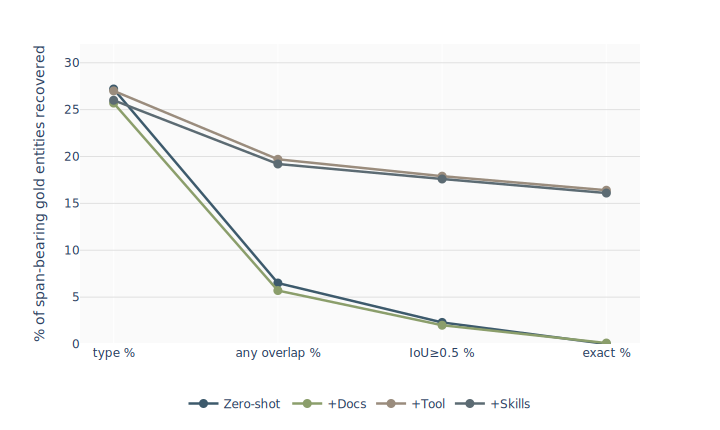

In [25]:
stages = ["type %", "any overlap %", "IoU≥0.5 %", "exact %"]
colors = {"Zero-shot": TEAL, "+Docs": SAGE, "+Tool": TAUPE, "+Skills": INK}

fig = go.Figure()
for _, row in df_funnel.iterrows():
    fig.add_trace(go.Scatter(
        x=stages, y=[row[s] for s in stages], mode="lines+markers", name=row["condition"],
        line=dict(color=colors[row["condition"]], width=2.5), marker=dict(size=9),
    ))

style(fig, "", h=430, w=720,
      yaxis=dict(title="% of span-bearing gold entities recovered", range=[0, 32], gridcolor="#e0e0e0"),
      xaxis=dict(title=""))

fig.show(renderer="svg"); fig.write_image("fig_offset_provenance.pdf")


### Span-bearing subset only, plus a strict entity-level metric

Reruns the headline comparison on genuinely span-annotated data and adds a strict (exact-boundary) entity metric. This is the undiluted version of the span result.


In [26]:
def f1x(preds, gt, nf, mode):
    """type | span (IoU>=0.5) | strict (exact boundary). Span checks apply only where gold has offsets."""
    vp = [p for p in preds if isinstance(p, dict) and "type" in p]
    if not gt: return 1.0 if not vp else 0.0
    if not vp: return 0.0
    used, tp = set(), 0

    for p in vp:
        pt = nf(p.get("type", ""))
        for k, t in enumerate(gt):
            if k in used or pt != nf(t.get("type", "")): continue
            hs = _sint(t, "start") or _sint(t, "end")
            if mode == "span" and hs and _iou(p, t) < 0.5: continue
            if mode == "strict" and hs and not (_sint(p, "start") == _sint(t, "start")
                                                and _sint(p, "end") == _sint(t, "end")): continue
            used.add(k); tp += 1; break

    pr, rc = tp / len(vp), tp / len(gt)

    return 2 * pr * rc / (pr + rc) if (pr + rc) else 0.0


def mean_f1x(recs, cond, mode, nf=norm):
    v = [f1x(r["predictions"] or [], r["ground_truth"] or [], nf, mode) for r in recs if r["condition"] == cond]

    return sum(v) / len(v) if v else float("nan")


span_only = [r for r in main if has_spans(r)]
rows = []
for c in CONDITIONS:
    rows.append({
        "condition": CLABEL[c],
        "type (all)": round(mean_f1x(main, c, "type"), 3),
        "span (all)": round(mean_f1x(main, c, "span"), 3),
        "strict (all)": round(mean_f1x(main, c, "strict"), 3),
        "type (span-bearing)": round(mean_f1x(span_only, c, "type"), 3),
        "span (span-bearing)": round(mean_f1x(span_only, c, "span"), 3),
        "strict (span-bearing)": round(mean_f1x(span_only, c, "strict"), 3),
    })

df_strict = pd.DataFrame(rows)

df_strict


,condition,type (all),span (all),strict (all),type (span-bearing),span (span-bearing),strict (span-bearing)
0,Zero-shot,0.631,0.325,0.303,0.581,0.040,0.001
1,+Docs,0.602,0.301,0.282,0.566,0.034,0.001
2,+Tool,0.527,0.455,0.435,0.520,0.393,0.356
3,+Skills,0.511,0.448,0.429,0.500,0.389,0.355


## 17. Label-map sensitivity: does the inversion depend on ADDRESS ≡ LOCATION?

Recomputes both headline metrics with the two consequential bridges (`ADDRESS→LOCATION`, `DATE→DATE_TIME`) switched on and off, to test whether the ranking inversion is an artifact of the alignment map.


In [27]:
BRIDGE_ADDR = {k: "LOCATION" for k in
               ["ADDRESS", "STREET", "STREET_ADDRESS", "STREET_NAME", "BUILDING",
                "BUILDING_NUMBER", "SECONDARY_ADDRESS", "SECADDRESS"]}
BRIDGE_DATE = {k: "DATE_TIME" for k in
               ["DATE", "DATEOFBIRTH", "DATETIME", "DATE_AND_TIME", "TIMESTAMP"]}
_BASE = {k: v for k, v in CANONICAL_ALIAS.items()
         if k not in BRIDGE_ADDR and k not in BRIDGE_DATE}


def _fallback_x(k, addr=True, date=True):
    """_fallback(), but the ADDRESS and DATE heuristics are toggleable. Removing a bridge from the
    alias map is not enough: the regex fallback would silently re-add it, making the test vacuous."""
    if _re.search(r"IPV?4|IPV?6|IP_?ADDR", k): return "IP_ADDRESS"
    if "ZIP" in k or "POSTAL" in k: return "ZIPCODE"
    if "SSN" in k or "SOCIAL_SEC" in k or "SOCIALSEC" in k: return "US_SOCIAL_SECURITY_NUMBER"
    if "PASSPORT" in k: return "US_PASSPORT_NUMBER"
    if "DRIVER" in k and "LICEN" in k: return "US_DRIVERS_LICENSE_NUMBER"
    if date and (k.startswith("DATE") or k.endswith("DATE") or "BIRTH" in k
                 or k in ("TIME",) or "TIMESTAMP" in k): return "DATE_TIME"
    if "EMAIL" in k: return "EMAIL_ADDRESS"
    if "PHONE" in k or "TELEPHONE" in k or k in ("TEL", "MOBILE", "FAX"): return "PHONE_NUMBER"
    if addr and ("ADDRESS" in k or k in ("CITY", "STATE", "COUNTRY", "COUNTY", "STREET")): return "LOCATION"

    return None


def make_norm(addr=True, date=True):
    """norm() with the two consequential bridges independently toggled, in map AND fallback."""
    alias = {**_BASE, **(BRIDGE_ADDR if addr else {}), **(BRIDGE_DATE if date else {})}

    def n(t):
        k = _key(t)
        if not k: return "UNKNOWN"
        if k in alias:
            v = alias[k]
            return v if v is not None else "UNKNOWN"

        return _fallback_x(k, addr, date) or k

    return n


rows = []
for label, (a, d) in [("full map", (1, 1)), ("no ADDRESS\u2261LOCATION", (0, 1)),
                      ("no DATE\u2261DATE_TIME", (1, 0)), ("neither bridge", (0, 0))]:
    nf = make_norm(a, d)
    ty = {c: mean_f1(main, c, nf, False) for c in CONDITIONS}
    sp = {c: mean_f1(main, c, nf, True) for c in CONDITIONS}
    inverts = ty["zero_shot"] > ty["with_tools"] and sp["zero_shot"] < sp["with_tools"]
    rows.append({
        "label map": label,
        "type ZS": round(ty["zero_shot"], 3), "type +Tool": round(ty["with_tools"], 3),
        "type ZS\u2212Tool": round(ty["zero_shot"] - ty["with_tools"], 3),
        "span ZS": round(sp["zero_shot"], 3), "span +Tool": round(sp["with_tools"], 3),
        "span ZS\u2212Tool": round(sp["zero_shot"] - sp["with_tools"], 3),
        "inversion holds": "yes" if inverts else "NO",
    })

df_mapsens = pd.DataFrame(rows)

df_mapsens


,label map,type ZS,type +Tool,type ZS−Tool,span ZS,span +Tool,span ZS−Tool,inversion holds
0,full map,0.631,0.527,0.104,0.325,0.455,-0.131,yes
1,no ADDRESS≡LOCATION,0.611,0.484,0.127,0.319,0.421,-0.102,yes
2,no DATE≡DATE_TIME,0.595,0.428,0.168,0.308,0.368,-0.060,yes
3,neither bridge,0.576,0.385,0.191,0.303,0.334,-0.031,yes


### Sensitivity figure

Shows the type-level and span-level zero-shot minus tool gaps under each label map. The gaps shrink without the bridges but never change sign, so the inversion is not an artifact of the alignment choice.


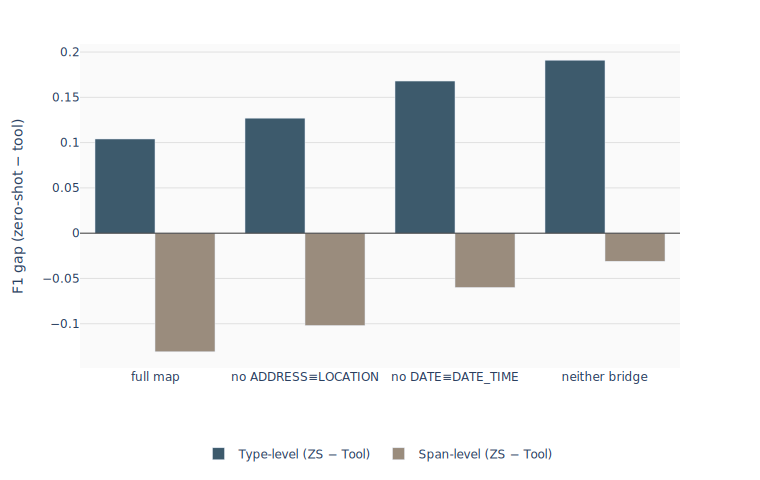

In [ ]:
fig = go.Figure()
fig.add_bar(name="Type-level (ZS − Tool)", x=df_mapsens["label map"], y=df_mapsens["type ZS−Tool"], marker_color=TEAL)
fig.add_bar(name="Span-level (ZS − Tool)", x=df_mapsens["label map"], y=df_mapsens["span ZS−Tool"], marker_color=TAUPE)
fig.add_hline(y=0, line_width=1, line_color="#333")

# Extra bottom margin so the horizontal legend is not clipped on PDF export.
style(fig, "", barmode="group", h=480, w=760,
      margin=dict(t=44, b=110),
      legend=dict(orientation="h", yanchor="top", y=-0.22, xanchor="center", x=0.5),
      yaxis=dict(title="F1 gap (zero-shot − tool)", gridcolor="#e0e0e0"))

fig.show(renderer="svg"); fig.write_image("fig_label_map_sensitivity.pdf")


## 18. Appendix: per-model offset provenance

Per-model breakdown of Section 16's headline table, on the span-bearing subset. This is the check that the exact-boundary collapse is uniform across models and not driven by a single weak one.


In [28]:
MODEL_LABEL = {"gemma2_9b": "Gemma 2 9B", "llama3_8b": "Llama 3.1 8B",
               "mistral_7b": "Mistral 7B", "qwen2_7b": "Qwen 2.5 7B"}

rows = []
for m in sorted({r["model"] for r in main}):
    for c in CONDITIONS:
        sub = [r for r in span_only if r["model"] == m and r["condition"] == c]
        f = lambda mode: sum(f1x(r["predictions"] or [], r["ground_truth"] or [], norm, mode)
                             for r in sub) / len(sub)
        rows.append({"model": MODEL_LABEL.get(m, m), "condition": CLABEL[c],
                     "type": round(f("type"), 3), "span": round(f("span"), 3),
                     "strict": round(f("strict"), 4)})

df_permodel = pd.DataFrame(rows)

zs = df_permodel[df_permodel.condition == "Zero-shot"]["strict"]
print(f"zero-shot strict F1 across models: {zs.min():.4f} to {zs.max():.4f} (uniform collapse)")

df_permodel


zero-shot strict F1 across models: 0.0002 to 0.0012 (uniform collapse)


,model,condition,type,span,strict
0,Gemma 2 9B,Zero-shot,0.568,0.045,0.0002
1,Gemma 2 9B,+Docs,0.604,0.044,0.0018
2,Gemma 2 9B,+Tool,0.513,0.397,0.3634
3,Gemma 2 9B,+Skills,0.514,0.398,0.3639
4,Llama 3.1 8B,Zero-shot,0.634,0.038,0.0003
5,Llama 3.1 8B,+Docs,0.474,0.028,0.0000
6,Llama 3.1 8B,+Tool,0.567,0.410,0.3653
7,Llama 3.1 8B,+Skills,0.490,0.372,0.3384
8,Mistral 7B,Zero-shot,0.527,0.035,0.0008
9,Mistral 7B,+Docs,0.542,0.027,0.0009
